In [27]:
import random
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")
import pandas as pd
import numpy as np
import seaborn as sns

from agents.agent import Agent , MomentumTrader
from market.market import Market

## Experiment 1
### Normal vs Momentum

In [28]:
normal_market = Market(
    current_price=100,
    sensitivity=0.08
)

normal_agents = []

for i in range(100):
    agent = Agent(
        identity=i,
        cash=random.randint(5000,15000),
        holdings=random.randint(20,100),
        risk_tolerance=random.uniform(0.2,0.9)
    )

    normal_agents.append(agent)

In [29]:
mixed_market = Market(
    current_price=100,
    sensitivity=0.08
)

mixed_agents = []

for i in range(50):
    mixed_agents.append(
        Agent(
            identity=i,
            cash=random.randint(5000,15000),
            holdings=random.randint(20,100),
            risk_tolerance=random.uniform(0.2,0.9)
        )
    )

for i in range(50):
    mixed_agents.append(
        MomentumTrader(
            identity=50+i,
            cash=random.randint(5000,15000),
            holdings=random.randint(20,100),
            risk_tolerance=random.uniform(0.2,0.9)
        )
    )

In [30]:
momentum_market = Market(
    current_price=100,
    sensitivity=0.08
)

momentum_agents = []

for i in range(100):
    momentum_agents.append(
        MomentumTrader(
            identity=i,
            cash=random.randint(5000,15000),
            holdings=random.randint(20,100),
            risk_tolerance=random.uniform(0.2,0.9)
        )
    )

In [31]:
def run_market(market, agents, ticks=500):

    previous_return = 0

    for tick in range(ticks):

        actions = []

        for agent in agents:

            act, vol = agent.action(
                market.current_price,
                previous_return
            )

            agent.update_values(
                market.current_price,
                act,
                vol
            )

            actions.append((act, vol))

        market.agents_act(actions)

        new_price = market.pricing(tick)

        previous_return = market.price_history[-1]["returns"]

        for agent in agents:

            agent.update_wealth(new_price)

    return market

In [32]:
normal_market = run_market(
    normal_market,
    normal_agents,
    ticks=500
)

mixed_market = run_market(
    mixed_market,
    mixed_agents,
    ticks=500
)

momentum_market = run_market(
    momentum_market,
    momentum_agents,
    ticks=500
)

In [33]:
def market_stats(market):

    prices = np.array(
        [x["price"] for x in market.price_history]
    )

    returns = np.diff(prices) / prices[:-1]

    total_volume = sum(
        x["buy_pressure"] + x["sell_pressure"]
        for x in market.price_history
    )

    return {
        "final_price": prices[-1],
        "volatility": np.std(returns),
        "volume": total_volume,
        "trend_persistence":
            pd.Series(returns).autocorr(lag=1)
    }

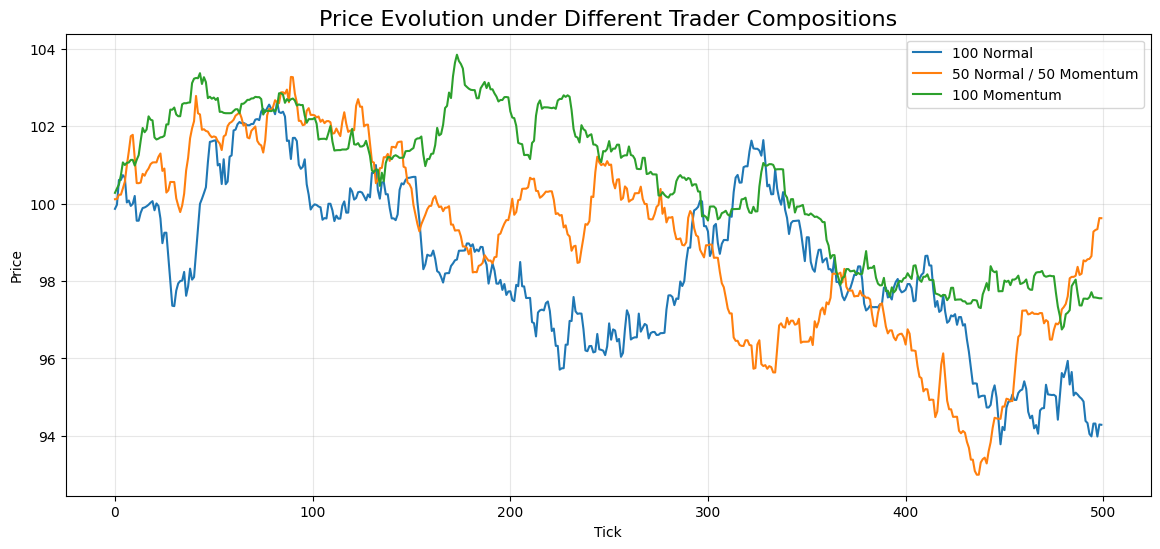

In [34]:
plt.figure(figsize=(14,6))

plt.plot(
    [x["price"] for x in normal_market.price_history],
    label="100 Normal"
)

plt.plot(
    [x["price"] for x in mixed_market.price_history],
    label="50 Normal / 50 Momentum"
)

plt.plot(
    [x["price"] for x in momentum_market.price_history],
    label="100 Momentum"
)

plt.title(
    "Price Evolution under Different Trader Compositions",
    fontsize=16
)

plt.xlabel("Tick")
plt.ylabel("Price")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Experiment 2
### Risk Tolerance Sweep

In [35]:
risk_levels = [0.2, 0.4, 0.6, 0.8]

markets = {}
agents_dict = {}

In [36]:
for risk in risk_levels:

    market = Market(
        current_price=100,
        sensitivity=0.08
    )

    agents = []

    # 50 Normal
    for i in range(70):

        agent = Agent(
            identity=i,
            cash=random.randint(8000,12000),
            holdings=random.randint(80,120),
            risk_tolerance=risk
        )

        agents.append(agent)

    # 50 Momentum
    for i in range(30):

        agent = MomentumTrader(
            identity=50+i,
            cash=random.randint(8000,12000),
            holdings=random.randint(80,120),
            risk_tolerance=risk
        )

        agents.append(agent)

    markets[risk] = market
    agents_dict[risk] = agents

In [37]:
TICKS = 500

for risk in risk_levels:

    market = markets[risk]
    agents = agents_dict[risk]

    previous_return = 0

    for tick in range(TICKS):

        actions = []

        for agent in agents:

            act, vol = agent.action(
                market.current_price,
                previous_return
            )

            agent.update_values(
                market.current_price,
                act,
                vol
            )

            actions.append((act, vol))

        market.agents_act(actions)

        new_price = market.pricing(tick)

        previous_return = market.price_history[-1]["returns"]

        for agent in agents:
            agent.update_wealth(new_price)

In [38]:
results = []

for risk in risk_levels:

    market = markets[risk]
    agents = agents_dict[risk]

    prices = np.array([
        x["price"]
        for x in market.price_history
    ])

    returns = np.diff(prices) / prices[:-1]

    avg_volume = np.mean([
        x["buy_pressure"] + x["sell_pressure"]
        for x in market.price_history
    ])

    volatility = np.std(returns)

    wealths = [
        a.cash + a.holdings * market.current_price
        for a in agents
    ]

    wealth_dispersion = np.std(wealths)

    results.append({
        "risk": risk,
        "avg_volume": avg_volume,
        "volatility": volatility,
        "wealth_dispersion": wealth_dispersion
    })

results_df = pd.DataFrame(results)

results_df

,risk,avg_volume,volatility,wealth_dispersion
0,0.2,72.568,0.003479,1522.897735
1,0.4,105.190,0.002889,1337.124822
2,0.6,147.792,0.002339,1618.601235
3,0.8,205.392,0.002043,1569.550919


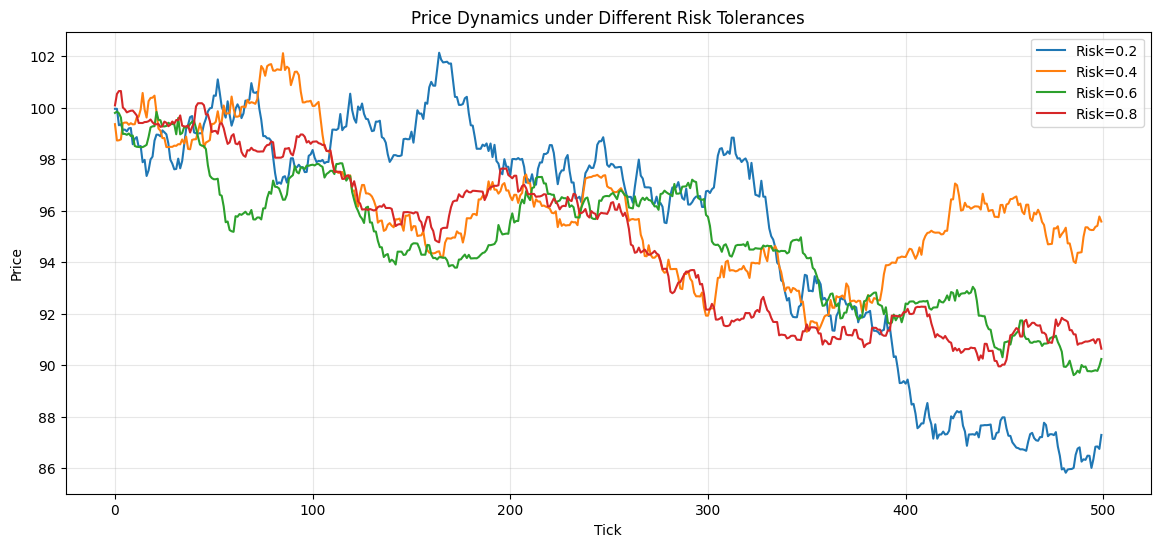

In [39]:
plt.figure(figsize=(14,6))

for risk in risk_levels:

    prices = [
        x["price"]
        for x in markets[risk].price_history
    ]

    plt.plot(
        prices,
        label=f"Risk={risk}"
    )

plt.title("Price Dynamics under Different Risk Tolerances")
plt.xlabel("Tick")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Running 30 Experiments to see what usually happens :

In [77]:
def calculate_metrics(market):

    prices = np.array([
        x["price"]
        for x in market.price_history
    ])

    returns = np.diff(prices) / prices[:-1]

    final_price = prices[-1]

    volatility = np.std(returns)

    running_max = np.maximum.accumulate(prices)

    drawdowns = (
        prices - running_max
    ) / running_max

    max_drawdown = abs(drawdowns.min())

    average_volume = np.mean([
        x["buy_pressure"] + x["sell_pressure"]
        for x in market.price_history
    ])

    return {
        "final_price": final_price,
        "volatility": volatility,
        "max_drawdown": max_drawdown,
        "average_volume": average_volume
    }

In [78]:
risk_levels = [0.2, 0.4, 0.6, 0.8]

N_RUNS = 50
TICKS = 500

results = []
diagnostics = []

In [79]:
for risk in risk_levels:

    print(f"Running Risk = {risk}")

    for run in range(N_RUNS):

        market = Market(
            current_price=100,
            sensitivity=0.08
        )

        agents = []

        # 50 Normal

        for i in range(50):

            agents.append(

                Agent(
                    identity=i,
                    cash=random.randint(8000,12000),
                    holdings=random.randint(80,120),
                    risk_tolerance=risk
                )

            )

        # 50 Momentum

        for i in range(50):

            agents.append(

                MomentumTrader(
                    identity=50+i,
                    cash=random.randint(8000,12000),
                    holdings=random.randint(80,120),
                    risk_tolerance=risk
                )

            )

        previous_return = 0

        tick_records = []

        for tick in range(TICKS):

            actions = []

            buy_count = 0
            sell_count = 0

            total_volume = 0

            tendencies = []

            for agent in agents:

                act, vol = agent.action(
                    market.current_price,
                    previous_return
                )

                if act == 1:
                    buy_count += 1

                elif act == -1:
                    sell_count += 1

                tendencies.append(
                    abs(agent.tendency_val)
                )

                total_volume += vol

                agent.update_values(
                    market.current_price,
                    act,
                    vol
                )

                actions.append((act, vol))

            market.agents_act(actions)

            new_price = market.pricing(tick)

            previous_return = market.price_history[-1]["returns"]

            for agent in agents:
                agent.update_wealth(new_price)

            tick_records.append({

                "risk": risk,
                "run": run,
                "tick": tick,

                "fraction_buying":
                    buy_count / len(agents),

                "fraction_selling":
                    sell_count / len(agents),

                "mean_abs_tendency":
                    np.mean(tendencies),

                "volume":
                    total_volume,

                "abs_return":
                    abs(
                        market.price_history[-1]["returns"]
                    ),

                "imbalance":
                    market.price_history[-1]["imbalance"]

            })

        prices = np.array([
            x["price"]
            for x in market.price_history
        ])

        returns = np.diff(prices) / prices[:-1]

        running_max = np.maximum.accumulate(prices)

        drawdowns = (
            prices - running_max
        ) / running_max

        max_drawdown = abs(
            drawdowns.min()
        )

        results.append({

            "risk": risk,
            "run": run,

            "final_price":
                prices[-1],

            "volatility":
                np.std(returns),

            "max_drawdown":
                max_drawdown,

            "average_volume":
                np.mean(
                    [x["volume"] for x in tick_records]
                )

        })

        diagnostics.extend(
            tick_records
        )

Running Risk = 0.2
Running Risk = 0.4
Running Risk = 0.6
Running Risk = 0.8


In [80]:
results_df = pd.DataFrame(results)

diagnostics_df = pd.DataFrame(diagnostics)

print(results_df.shape)
print(diagnostics_df.shape)

results_df.head()

(200, 6)
(100000, 9)


,risk,run,final_price,volatility,max_drawdown,average_volume
0,0.2,0,92.915263,0.002964,0.150174,98.956
1,0.2,1,94.195380,0.002558,0.074544,101.594
2,0.2,2,84.990958,0.002845,0.170030,99.216
3,0.2,3,96.696255,0.002917,0.162123,96.150
4,0.2,4,100.482208,0.002887,0.069232,100.590


In [81]:
summary = (
    results_df
    .groupby("risk")
    .agg({
        "final_price":["mean","std"],
        "volatility":["mean","std"],
        "max_drawdown":["mean","std"],
        "average_volume":["mean","std"]
    })
)

summary

final_price           volatility           max_drawdown            \
            mean       std       mean       std         mean       std   
risk                                                                     
0.2    89.738913  4.200502   0.002785  0.000091     0.132335  0.030382   
0.4    89.988665  2.946153   0.002424  0.000090     0.119328  0.025371   
0.6    89.952841  2.408540   0.002158  0.000105     0.113877  0.020746   
0.8    90.070876  1.943416   0.001922  0.000082     0.111861  0.016815   

     average_volume            
               mean       std  
risk                           
0.2        101.7250  2.676778  
0.4        133.1010  3.499059  
0.6        169.5902  3.518830  
0.8        216.0420  4.259633

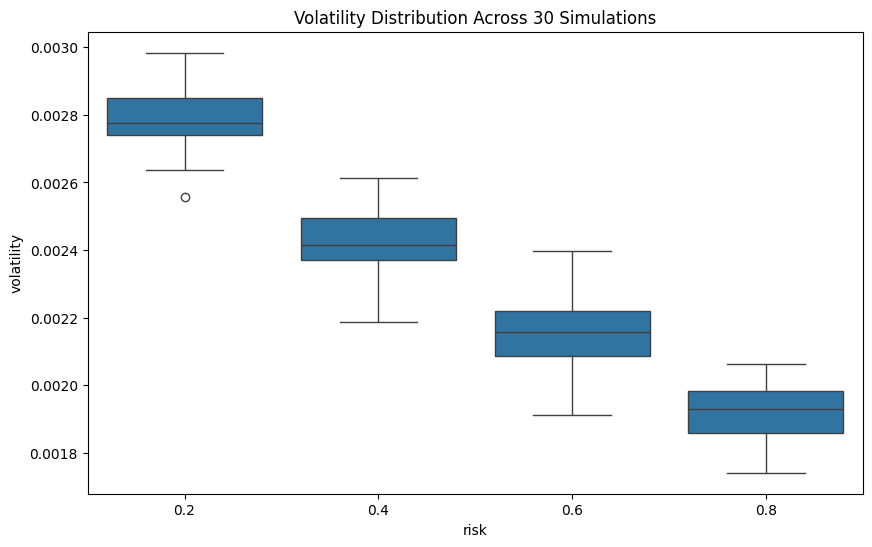

In [82]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=results_df,
    x="risk",
    y="volatility"
)

plt.title(
    "Volatility Distribution Across 30 Simulations"
)

plt.show()

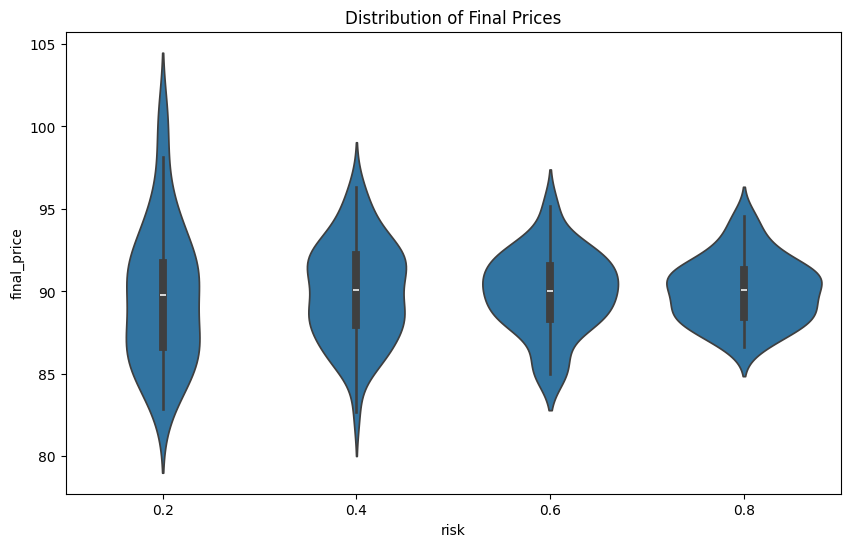

In [83]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=results_df,
    x="risk",
    y="final_price"
)

plt.title(
    "Distribution of Final Prices"
)

plt.show()

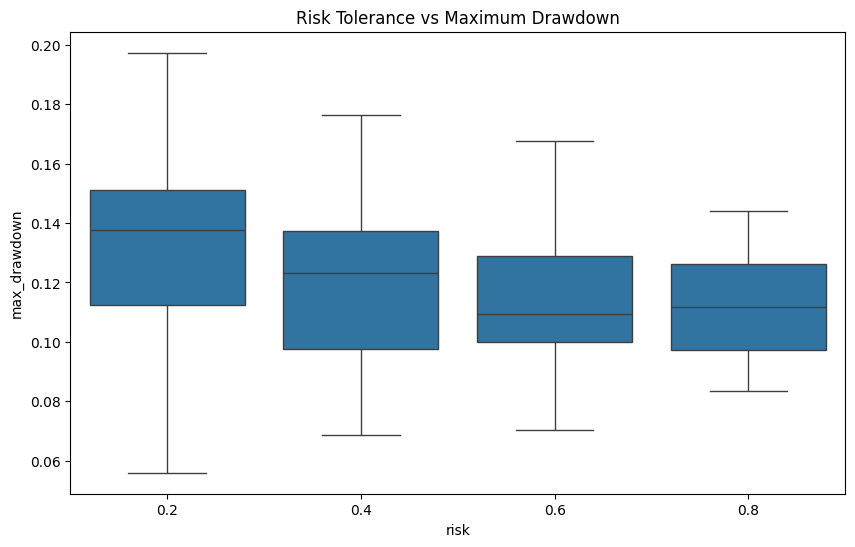

In [84]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=results_df,
    x="risk",
    y="max_drawdown"
)

plt.title(
    "Risk Tolerance vs Maximum Drawdown"
)

plt.show()

In [48]:
vol_summary = (
    results_df
    .groupby("risk")["volatility"]
    .agg(["mean","std"])
)

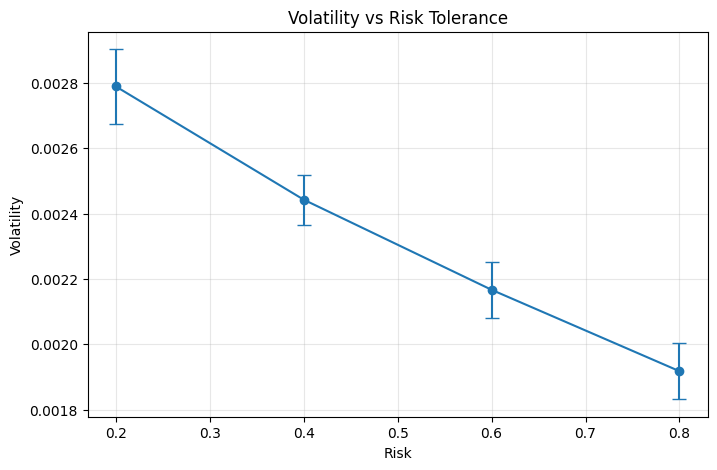

In [49]:
plt.figure(figsize=(8,5))

plt.errorbar(
    vol_summary.index,
    vol_summary["mean"],
    yerr=vol_summary["std"],
    marker="o",
    capsize=5
)

plt.title(
    "Volatility vs Risk Tolerance"
)

plt.xlabel("Risk")
plt.ylabel("Volatility")

plt.grid(alpha=0.3)

plt.show()

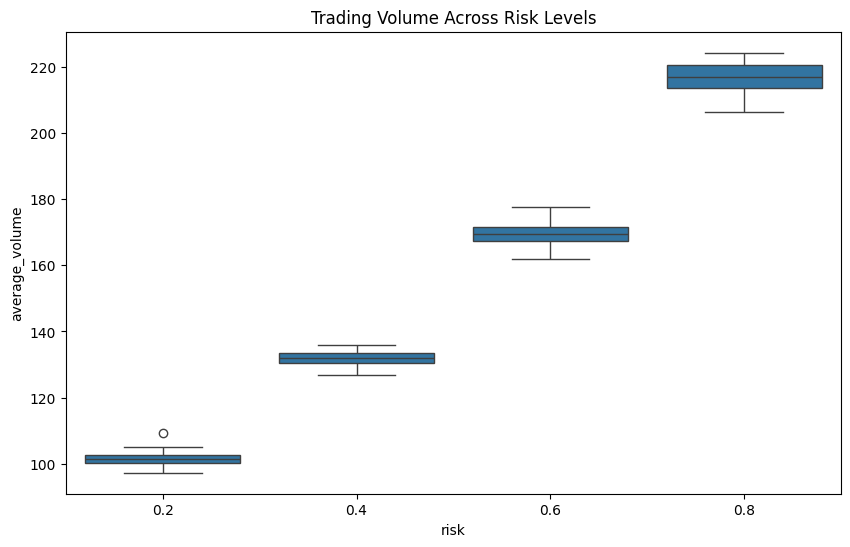

In [50]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=results_df,
    x="risk",
    y="average_volume"
)

plt.title(
    "Trading Volume Across Risk Levels"
)

plt.show()

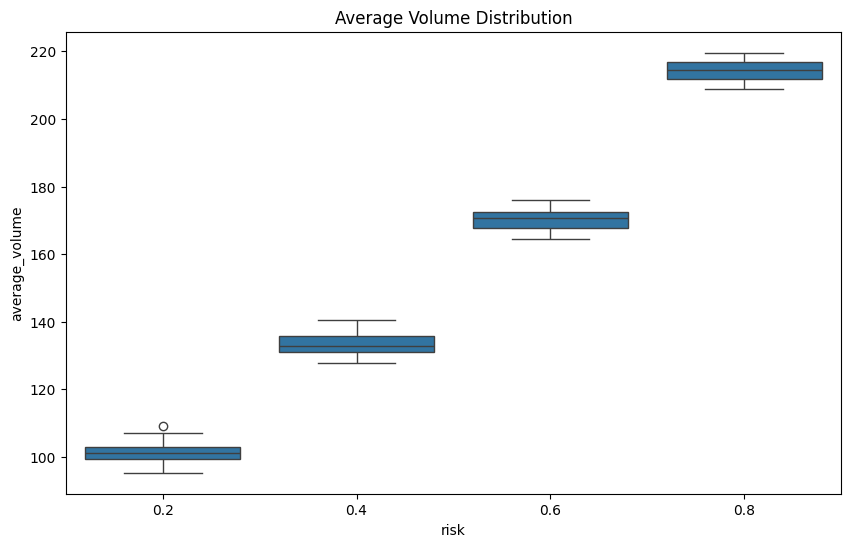

In [58]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=results_df,
    x="risk",
    y="average_volume"
)

plt.title(
    "Average Volume Distribution"
)

plt.show()

In [61]:
sync_df = (

    diagnostics_df

    .groupby(["risk","run"])

    .apply(

        lambda x:

        np.mean(

            np.maximum(

                x["fraction_buying"],

                x["fraction_selling"]

            )

        )

    )

    .reset_index(name="sync")

)

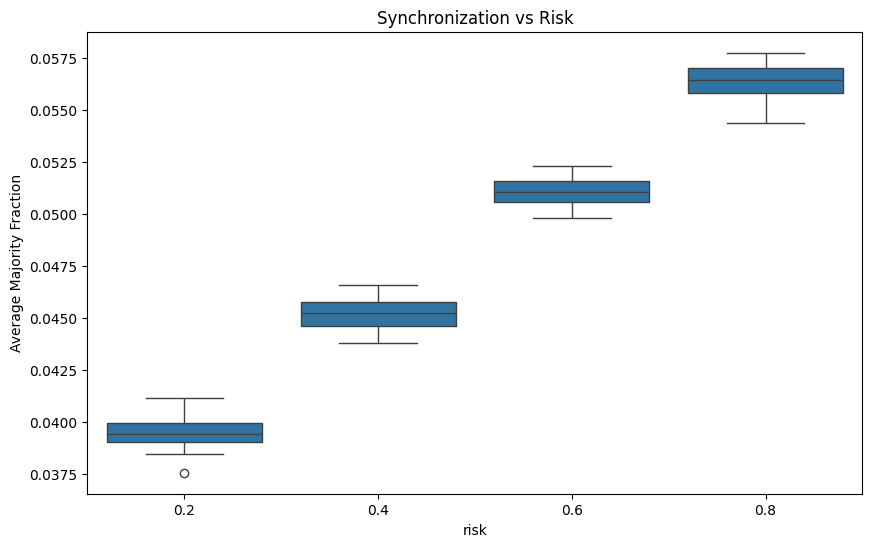

In [62]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=sync_df,
    x="risk",
    y="sync"
)

plt.title(
    "Synchronization vs Risk"
)

plt.ylabel(
    "Average Majority Fraction"
)

plt.show()

In [63]:
conviction_df = (

    diagnostics_df

    .groupby(["risk","run"])

    ["mean_abs_tendency"]

    .mean()

    .reset_index()

)

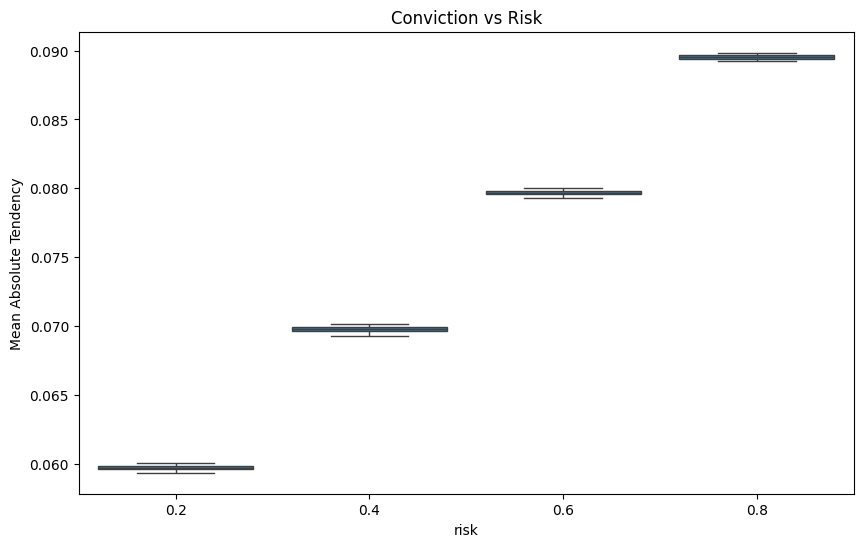

In [65]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=conviction_df,
    x="risk",
    y="mean_abs_tendency"
)

plt.title(
    "Conviction vs Risk"
)

plt.ylabel(
    "Mean Absolute Tendency"
)

plt.show()

In [66]:
sample = diagnostics_df.sample(
    5000,
    random_state=42
)

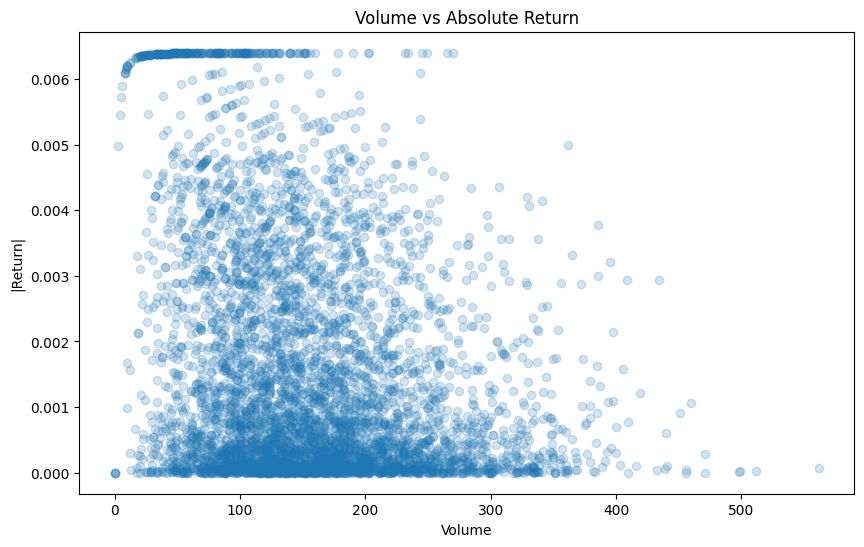

In [67]:
plt.figure(figsize=(10,6))

plt.scatter(

    sample["volume"],

    sample["abs_return"],

    alpha=0.2

)

plt.xlabel("Volume")

plt.ylabel("|Return|")

plt.title(
    "Volume vs Absolute Return"
)

plt.show()

In [69]:
for risk in risk_levels:

    subset = diagnostics_df[
        diagnostics_df["risk"] == risk
    ]

    corr = subset["volume"].corr(
        subset["abs_return"]
    )

    print(
        f"Risk={risk:.1f}  Correlation={corr:.4f}"
    )

Risk=0.2  Correlation=-0.2981
Risk=0.4  Correlation=-0.2748
Risk=0.6  Correlation=-0.2453
Risk=0.8  Correlation=-0.2063


In [72]:
liquidity_df = diagnostics_df.copy()

liquidity_df["volume_bin"] = pd.qcut(

    liquidity_df["volume"],

    q=10,

    duplicates="drop"

)

In [73]:
binned = (

    liquidity_df

    .groupby("volume_bin")

    ["abs_return"]

    .mean()

)

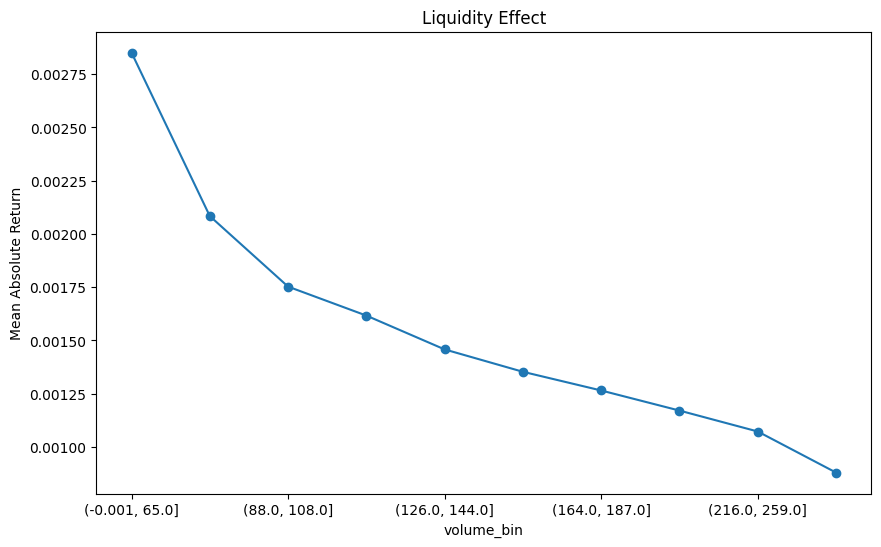

In [75]:
plt.figure(figsize=(10,6))

binned.plot(
    marker="o"
)

plt.ylabel(
    "Mean Absolute Return"
)

plt.title(
    "Liquidity Effect"
)

plt.show()

In [ ]:
sample = diagnostics_df.sample(
    10000,
    random_state=42
)

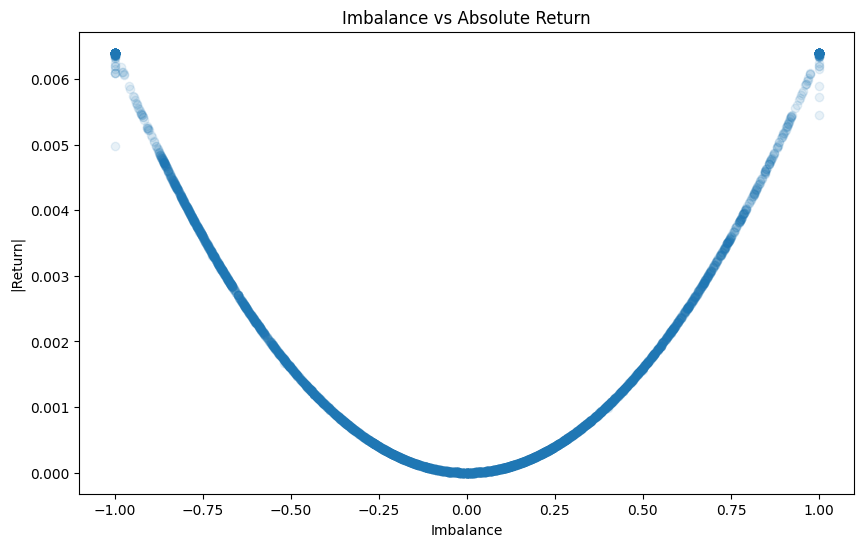

In [76]:
plt.figure(figsize=(10,6))

plt.scatter(

    sample["imbalance"],

    sample["abs_return"],

    alpha=0.1

)

plt.xlabel("Imbalance")

plt.ylabel("|Return|")

plt.title(
    "Imbalance vs Absolute Return"
)

plt.show()